Welcome to the second lab of the 'Probabilistic and Statistical Inference' course. Please use this Jupyter Notebook to implement your solutiuons. You can use existing libraries, but you are not allowed to use functions that solve a task directly. For problems with theoretical calculations, you need to show a sufficient number of intermediate steps to explain how you have obtained the result. Formulas are expected in LaTeX style inside the notebook using Markdown cells. The assignment should be uploaded in Jupyter Notebook format(`.ipynb`).

**Your code should work without errors from the beginnning to the end of the notebook**. A good practice to achieve this is to use 'Run > Restart kernel and run all cells...' command from the top menu to check the notebook before submitting.

Maximum score for this lab is 20 points. Bonus points: additional tasks to improve your score, but not above the maximum of 20.

 The objective of this lab is to have a clear understanding of the properties of statistical estimators, their asymptotic normality, the efficiency, and constructing their confidence intervals.
 For illustrative purposes, we will use a very simple statistical problem concerning the estimation
 of the mean from a sample, but the observations apply to other statistical procedures as well.

 Some hints are provided at the end of the document.

In [1]:
import numpy as np
import scipy
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline


np.random.seed(31337)

# Part 1: Estimators and their asymptotic normality (3 points)

 ## Task 1.1 (1 point)
 Draw a sample of size $n = 20$ from the standard normal distribution (with mean
 $0$ and standard deviation $1$, denoted by $\mathcal{P}_1$). Compute three estimators: **sample mean**, **sample median** and **range-estimator** based on $(\max(X_i) + \min(X_i))/2$, which are three statistics we are interested in.





In [2]:
# TODO: Your code here
n = 20

X = np.random.normal(loc=0.0, scale=1.0, size=n)
sample_mean = np.mean(X)
sample_median = np.median(X)
range_estimator = (np.max(X) + np.min(X)) / 2.0

print(f"sample mean: {sample_mean:.4f}")
print(f"sample median: {sample_median:.4f}")
print(f"range-estimator: {range_estimator:.4f}")

sample mean: -0.0488
sample median: 0.0828
range-estimator: -0.2947


## Task 1.2 (1 point)
Repeat the above Task $1000$ times. Draw the histogram of the calculated sample
 mean (the sample median, the range-estimator), which shows the sampling distribution of
 the statistics. Compare this empirical distribution for sample mean with the theoretical
 sampling distribution, which is a normal distribution. Does the distribution of sample
 median or range estimator look like normal?

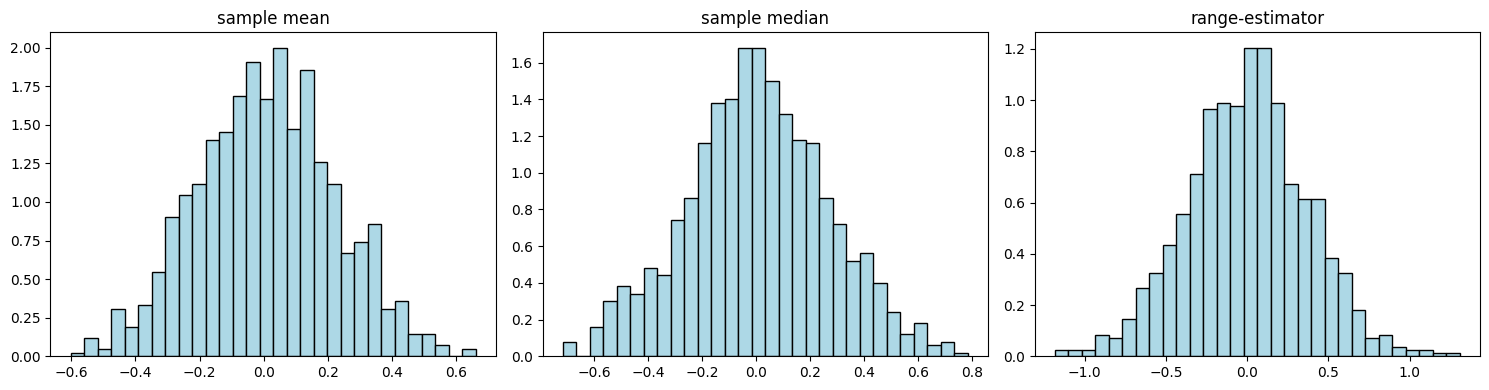

In [3]:
# TODO: Your code here
num_times = 1000

means = []
medians = []
ranges = []

for _ in range(num_times):
    X = np.random.normal(loc=0.0, scale=1.0, size=n)
    means.append(np.mean(X))
    medians.append(np.median(X))
    ranges.append((np.max(X) + np.min(X)) / 2.0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(means, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("sample mean")

plt.subplot(1, 3, 2)
plt.hist(medians, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("sample median")

plt.subplot(1, 3, 3)
plt.hist(ranges, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("range-estimator")

plt.tight_layout()
plt.show()

Your answer:
 - The empirical distribution of the sample mean is approximately normal
 - The sample median distribution also resembles a normal distribution but not as closely, having larger spread
 - The range-estimator looks symmetric, but it has a larger tails and has flatter center than normal

 ## Task 1.3 (1 point)
 Repeat Task 2 using sample sizes $n = 100, \: 1000, \: 10000$ and check the asymptotic normality of the above three estimators with some plots.

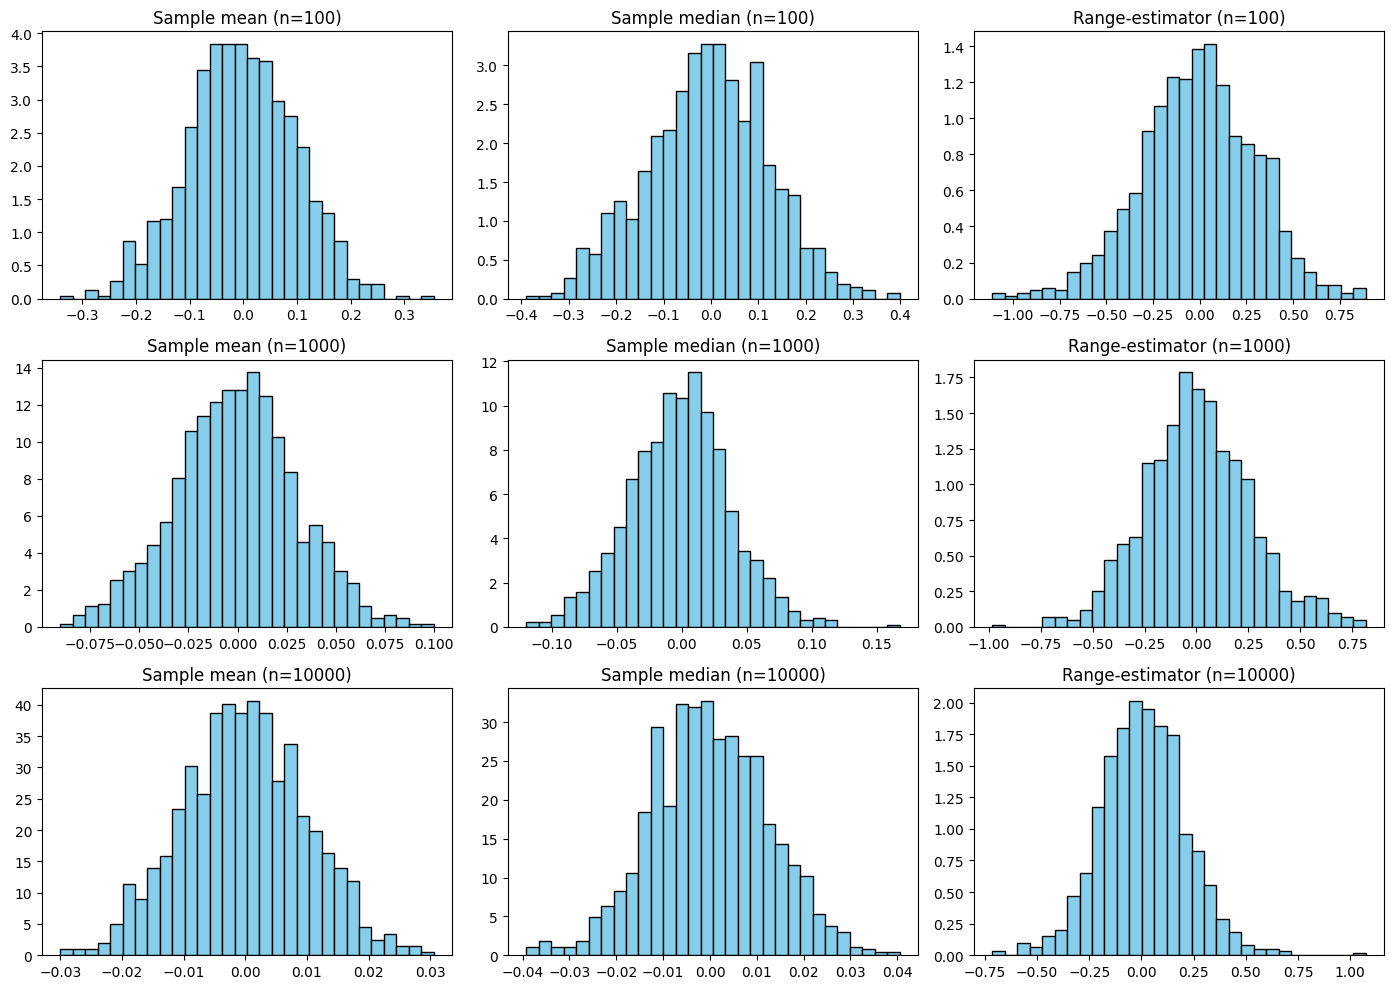

In [4]:
# TODO: Your code here
sample_sizes = [100, 1000, 10000]
num_times = 1000

fig, axes = plt.subplots(len(sample_sizes), 3, figsize=(14, 10))

for i, n in enumerate(sample_sizes):
    means, medians, ranges = [], [], []
    for _ in range(num_times):
        X = np.random.normal(0, 1, n)
        means.append(np.mean(X))
        medians.append(np.median(X))
        ranges.append((np.max(X) + np.min(X)) / 2.0)

    means, medians, ranges = np.array(means), np.array(medians), np.array(ranges)

    axes[i, 0].hist(means, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"Sample mean (n={n})")

    axes[i, 1].hist(medians, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 1].set_title(f"Sample median (n={n})")

    axes[i, 2].hist(ranges, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 2].set_title(f"Range-estimator (n={n})")

plt.tight_layout()
plt.show()

Your answer:
 - As the sample size n increases, the distributions of the three estimators gradually become concentrated and approach a normal.

# Part 2: Compare the efficiency of different estimators (2 points)

Define the asymptotic relative efficiency ($\mathrm{ARE}$) of $U_n$ to $T_n$ by $\mathrm{ARE}(U_n,T_n) = Var(U_n)/Var(T_n)$. We say that the estimator with the smaller (asymptotic) variance is more (asymptotically) efficient than another with larger variance. If $Var(U_n) < Var(T_n)$, then we know $U_n$ is more (asymptotically) efficient than $T_n$.

## Task 2.1 (2 point)
Compare the efficiency of the sample mean and the sample median. Plot the
 $\mathrm{ARE}$(the sample mean, the sample median), and check which is more (asymptotically) efficient.

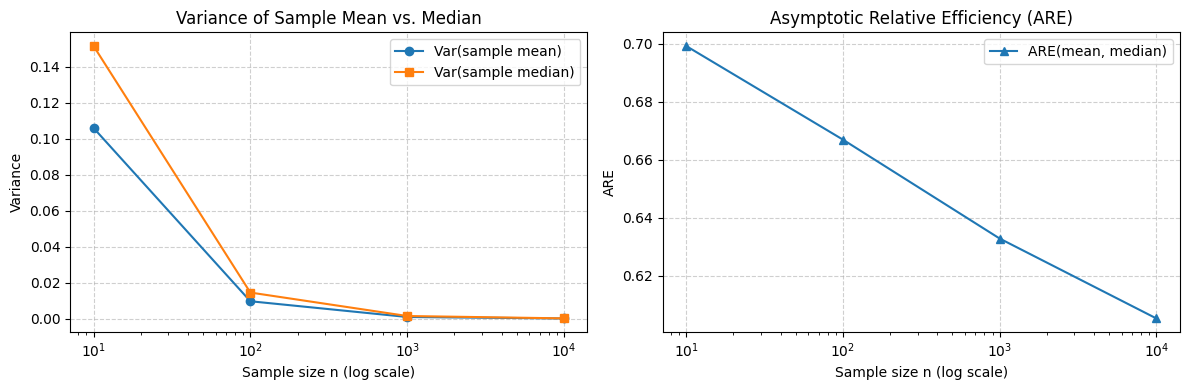

n=  10: Empirical ARE ≈ 0.6993
n= 100: Empirical ARE ≈ 0.6670
n=1000: Empirical ARE ≈ 0.6328
n=10000: Empirical ARE ≈ 0.6052


In [5]:
# TODO: Your code here

ns = [10, 100, 1000, 10000]
num_times = 1000
var_mean_list = []
var_median_list = []
are_list = []

for n in ns:
    X = np.random.normal(0, 1, size=(num_times, n))
    means = X.mean(axis=1)
    medians = np.median(X, axis=1)

    var_mean = np.var(means, ddof=1)
    var_median = np.var(medians, ddof=1)
    are=var_mean / var_median

    var_mean_list.append(var_mean)
    var_median_list.append(var_median)
    are_list.append(are)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# variance
axes[0].plot(ns, var_mean_list, 'o-', label='Var(sample mean)')
axes[0].plot(ns, var_median_list, 's-', label='Var(sample median)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size n (log scale)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Variance of Sample Mean vs. Median')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# ARE
axes[1].plot(ns, are_list, '^-', label='ARE(mean, median)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size n (log scale)')
axes[1].set_ylabel('ARE')
axes[1].set_title('Asymptotic Relative Efficiency (ARE)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

for n, a in zip(ns, are_list):
    print(f"n={n:>4d}: Empirical ARE ≈ {a:.4f}")

Your answer:
 - Sample mean has smaller variance, so it's more efficient

# Part 3: Sample from Laplace distribution (4 points)

 Do tasks in Section 1 - Section 2 again, but draw samples from the Laplace distribution with mean $0$ and variance $1$ (denoted by
 $\mathcal{P_2}$). You can vary the sample size from $n = 20, \: 100, \: 1000, \: \cdots$.

 Note: when we take Laplace data and do the same tasks as in Section 1, we should observe that the sample median is “better” than the sample mean.

## Task 3.1 (1 point)


In [6]:
# TODO: Your code here
b = 1 / np.sqrt(2)
loc = 0

n = 20
X = np.random.laplace(loc=loc, scale=b, size=n)

sample_mean = np.mean(X)
sample_median = np.median(X)
range_estimator = (np.max(X) + np.min(X)) / 2

print(f"sample mean: {sample_mean:.4f}")
print(f"sample median: {sample_median:.4f}")
print(f"range-estimator: {range_estimator:.4f}")

sample mean: 0.3907
sample median: 0.2441
range-estimator: 0.5348


## Task 3.2 (1 point)


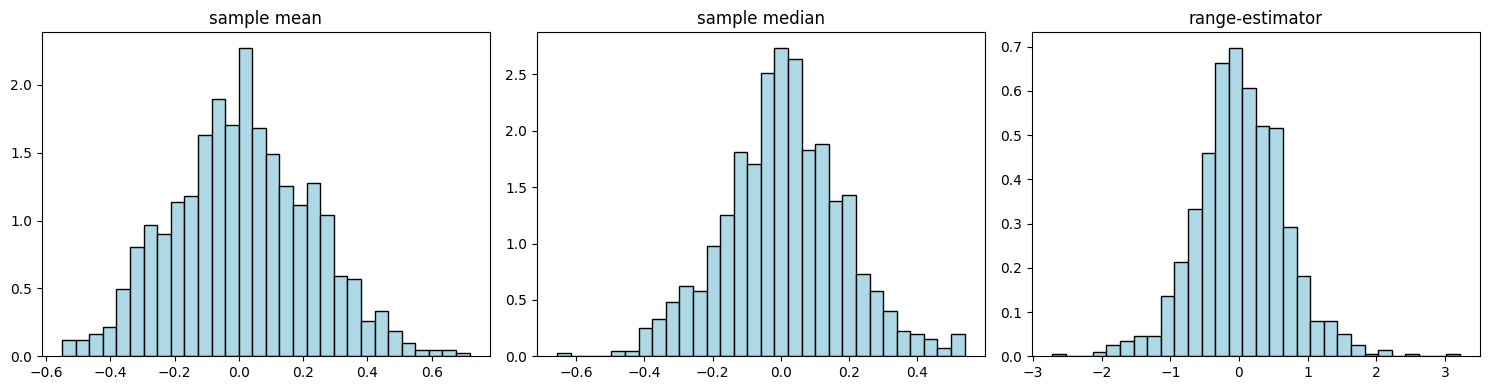

In [7]:
# TODO: Your code here
num_times = 1000
means, medians, ranges = [], [], []
for _ in range(num_times):
    X = np.random.laplace(loc=loc, scale=b, size=n)
    means.append(np.mean(X))
    medians.append(np.median(X))
    ranges.append((np.max(X) + np.min(X)) / 2)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(means, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("sample mean")

plt.subplot(1, 3, 2)
plt.hist(medians, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("sample median")

plt.subplot(1, 3, 3)
plt.hist(ranges, bins=30, density=True, color='lightblue', edgecolor='black')
plt.title("range-estimator")

plt.tight_layout()
plt.show()

Your answer:
 - The sample mean distribution has a larger variance and a more asymmetric shape
 - The sample **median** distribution is more concentrated, has a smaller variance, and is closer to symmetry
 - The range-estimator distribution is highly affected by extreme values

## Task 3.3 (1 point)

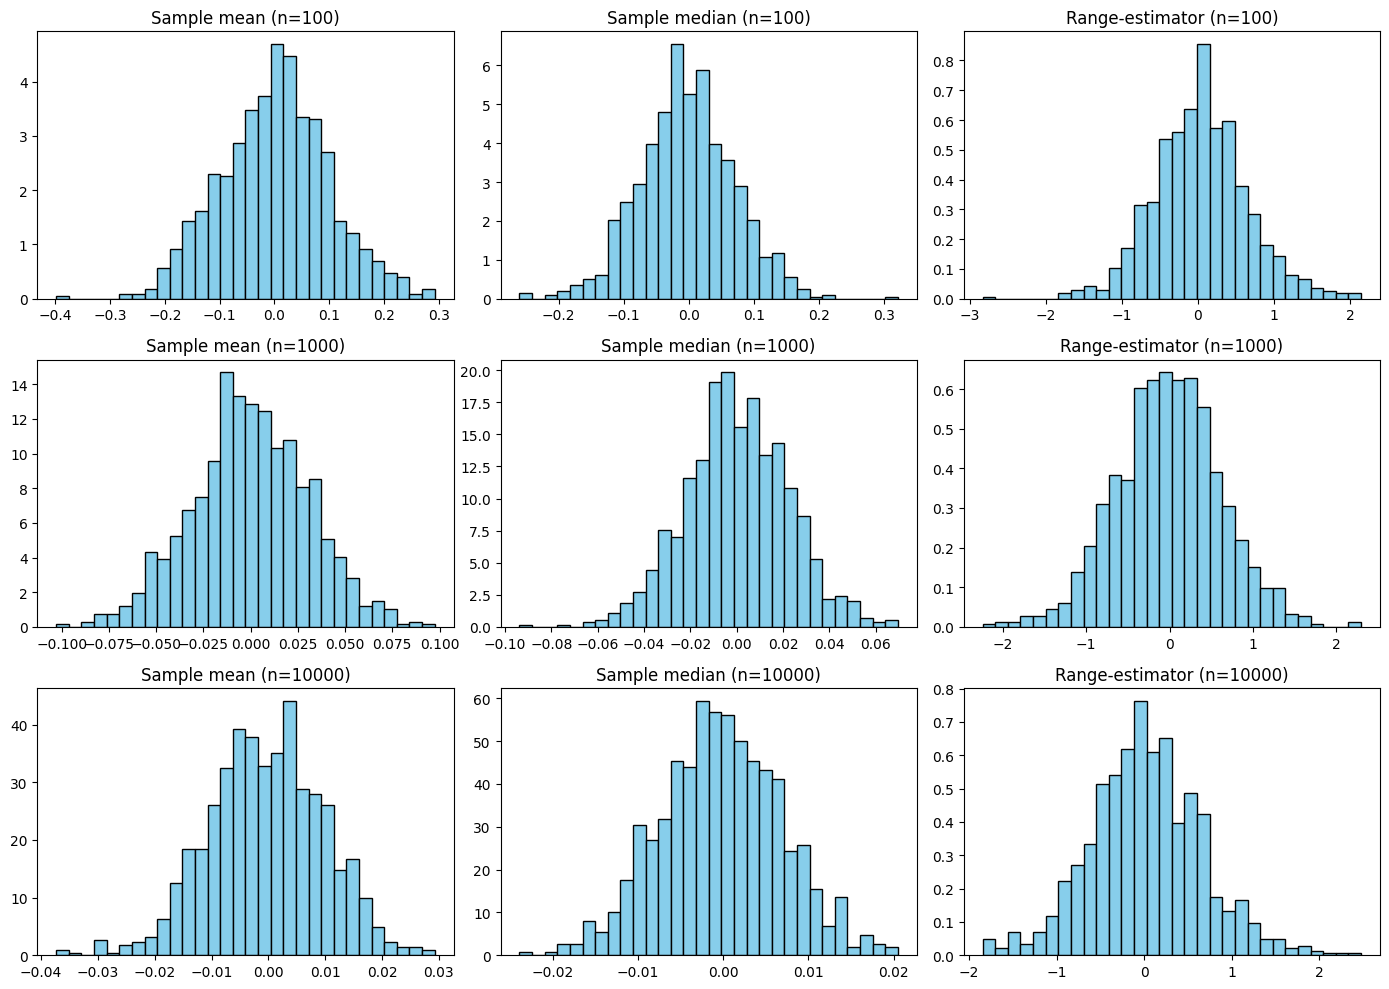

In [8]:
# TODO: Your code here
b = 1 / np.sqrt(2)
loc = 0
sample_sizes = [100, 1000, 10000]
num_times = 1000

fig, axes = plt.subplots(len(sample_sizes), 3, figsize=(14, 10))

for i, n in enumerate(sample_sizes):
    means, medians, ranges = [], [], []
    for _ in range(num_times):
        X = np.random.laplace(loc=loc, scale=b, size=n)
        means.append(np.mean(X))
        medians.append(np.median(X))
        ranges.append((np.max(X) + np.min(X)) / 2.0)

    means, medians, ranges = np.array(means), np.array(medians), np.array(ranges)

    axes[i, 0].hist(means, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"Sample mean (n={n})")

    axes[i, 1].hist(medians, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 1].set_title(f"Sample median (n={n})")

    axes[i, 2].hist(ranges, bins=30, density=True, color='skyblue', edgecolor='black')
    axes[i, 2].set_title(f"Range-estimator (n={n})")

plt.tight_layout()
plt.show()

Your answer:
 - As the sample size n increases, the distributions of the three estimators gradually become concentrated and approach a normal. But this time, the sample **median** distribution is more like normal.

## Task 3.4 (2 points)

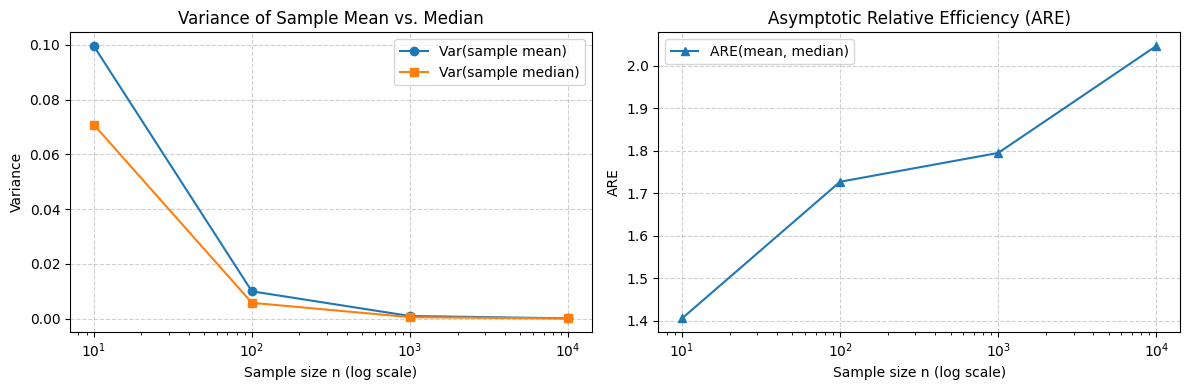

n=  10: Empirical ARE ≈ 1.4054
n= 100: Empirical ARE ≈ 1.7273
n=1000: Empirical ARE ≈ 1.7951
n=10000: Empirical ARE ≈ 2.0470


In [9]:
# TODO: Your code here
b = 1 / np.sqrt(2)
loc = 0
ns = [10, 100, 1000, 10000]
num_times = 1000
var_mean_list = []
var_median_list = []
are_list = []

for n in ns:
    X = np.random.laplace(loc=loc, scale=b, size=(num_times, n))
    means = X.mean(axis=1)
    medians = np.median(X, axis=1)

    var_mean = np.var(means, ddof=1)
    var_median = np.var(medians, ddof=1)
    are=var_mean / var_median

    var_mean_list.append(var_mean)
    var_median_list.append(var_median)
    are_list.append(are)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# variance
axes[0].plot(ns, var_mean_list, 'o-', label='Var(sample mean)')
axes[0].plot(ns, var_median_list, 's-', label='Var(sample median)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size n (log scale)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Variance of Sample Mean vs. Median')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# ARE
axes[1].plot(ns, are_list, '^-', label='ARE(mean, median)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size n (log scale)')
axes[1].set_ylabel('ARE')
axes[1].set_title('Asymptotic Relative Efficiency (ARE)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

for n, a in zip(ns, are_list):
    print(f"n={n:>4d}: Empirical ARE ≈ {a:.4f}")

Your answer:
 - Sample **median** has smaller variance, so it's more efficient

# Part 4: Confidenceintervals and coverage probability (5 points)



## Task 4.1 (2 points)
Sample from standard normal distribution. Construct confidence interval for
 sample mean and compare the observed empirical coverage with the nominal level ($1 - \alpha = 0.95$, $\alpha = 0.05$) by repeating your experiment multiple times. Additionally, you should calculate the width of the resulting invervals.

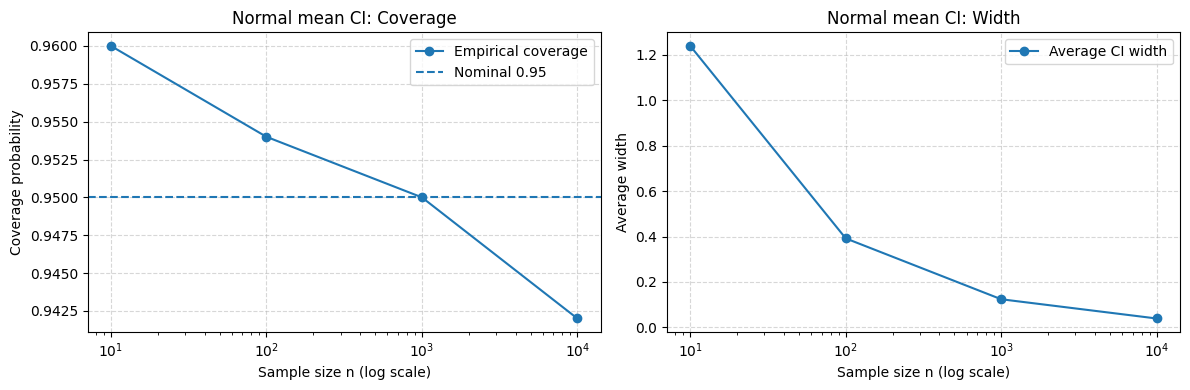

n=  10: coverage≈0.9600, avg width≈1.2396
n= 100: coverage≈0.9540, avg width≈0.3920
n=1000: coverage≈0.9500, avg width≈0.1240
n=10000: coverage≈0.9420, avg width≈0.0392


In [10]:
# Your code here
def ci_mean_normal_known_sigma(xbar, n, alpha=0.05, sigma=1.0):
    z = scipy.stats.norm.ppf(1 - alpha/2)
    half = z * sigma / np.sqrt(n)
    return (xbar - half, xbar + half), 2 * half

def simulate_normal_ci(n_list=(10, 20, 50, 100, 200, 500, 1000), trials=1000, alpha=0.05):
    coverages, widths = [], []
    for n in n_list:
        X = np.random.normal(loc=0.0, scale=1.0, size=(trials, n))
        xb = X.mean(axis=1)
        L = xb - scipy.stats.norm.ppf(1 - alpha/2) / np.sqrt(n)
        U = xb + scipy.stats.norm.ppf(1 - alpha/2) / np.sqrt(n)
        covered = ((L <= 0) & (U >= 0)).mean()
        avg_width = (U - L).mean()
        coverages.append(covered)
        widths.append(avg_width)
    return np.array(coverages), np.array(widths)

ns = [10, 100, 1000, 10000]
cov, wid = simulate_normal_ci(ns, trials=1000, alpha=0.05)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ns, cov, marker='o', label='Empirical coverage')
axes[0].axhline(0.95, linestyle='--', label='Nominal 0.95')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample size n (log scale)')
axes[0].set_ylabel('Coverage probability')
axes[0].set_title('Normal mean CI: Coverage')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(ns, wid, marker='o', label='Average CI width')
axes[1].set_xscale('log')
axes[1].set_xlabel('Sample size n (log scale)')
axes[1].set_ylabel('Average width')
axes[1].set_title('Normal mean CI: Width')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

for n, c, w in zip(ns, cov, wid):
    print(f"n={n:4d}: coverage≈{c:.4f}, avg width≈{w:.4f}")

Your conclusions:
 - The empirical coverage is close to the nominal level of 0.95, and will become closer as n increases
 - The interval width will decrease as n increases 

## Task 4.2 (3 points)

Sample from Bernoulli distribution, $\mathrm{Ber}(p)$. Finally we take Bernoulli data and compare different types of confidence intervals, one based on asymptotic normality the  other one based on Hoeffding inequality. You can vary sample size $n = 20, \: 100, \: 1000$ and $p = 0.2, \: 0.4, \: 0.5, \: 0.8$, and check different plots.

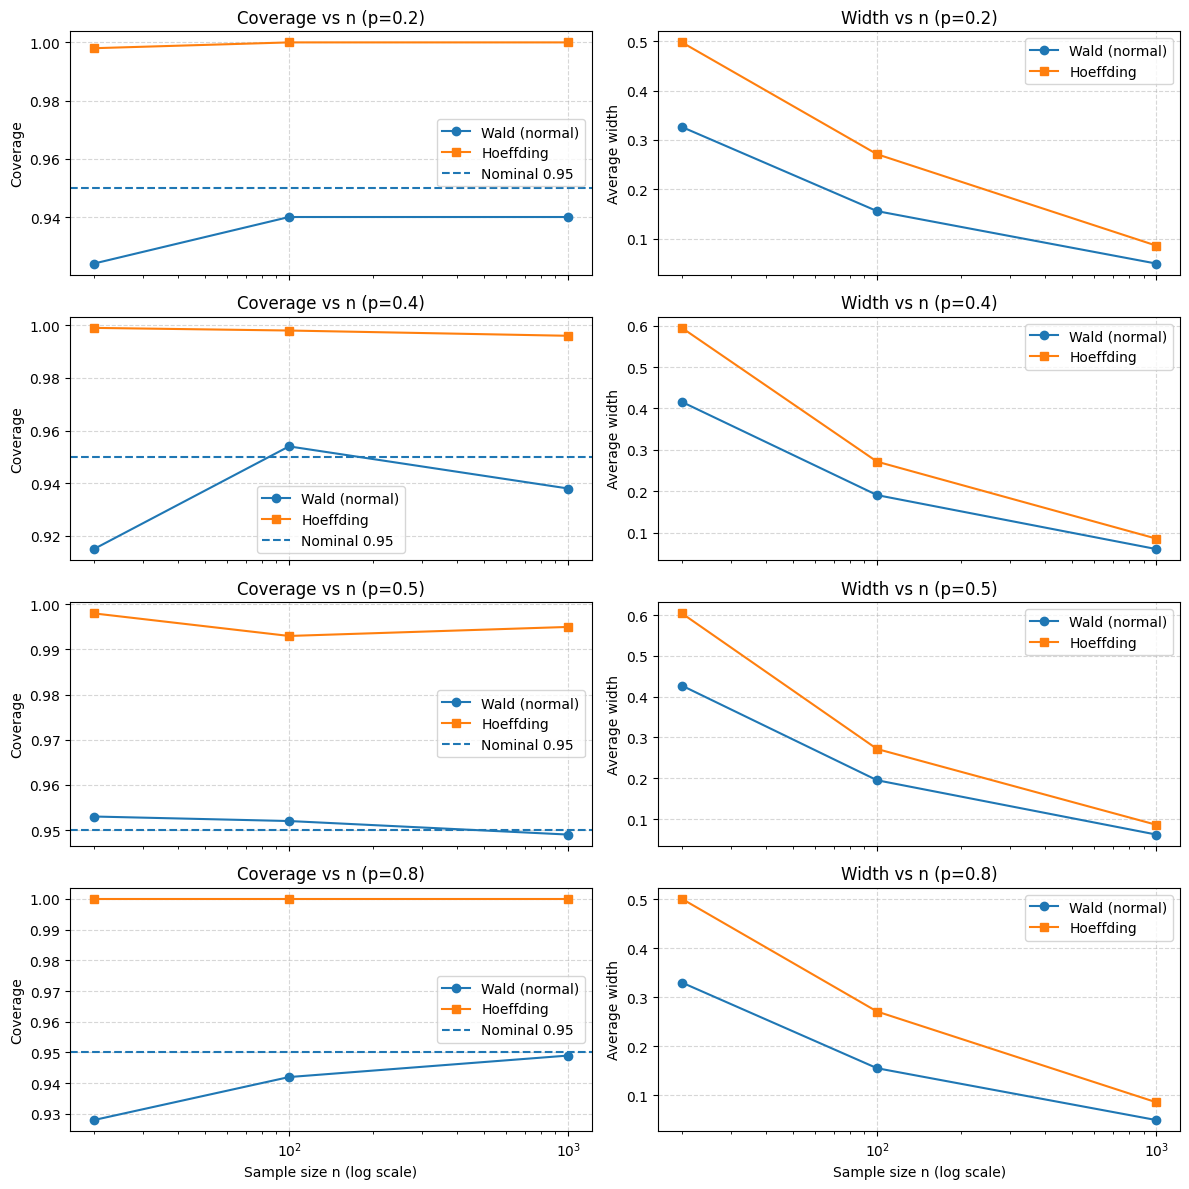


=== p = 0.2 ===
n=  20: Wald  cov≈0.924, width≈0.326 | Hoeffding cov≈0.998, width≈0.497
n= 100: Wald  cov≈0.940, width≈0.156 | Hoeffding cov≈1.000, width≈0.271
n=1000: Wald  cov≈0.940, width≈0.050 | Hoeffding cov≈1.000, width≈0.086

=== p = 0.4 ===
n=  20: Wald  cov≈0.915, width≈0.416 | Hoeffding cov≈0.999, width≈0.594
n= 100: Wald  cov≈0.954, width≈0.191 | Hoeffding cov≈0.998, width≈0.272
n=1000: Wald  cov≈0.938, width≈0.061 | Hoeffding cov≈0.996, width≈0.086

=== p = 0.5 ===
n=  20: Wald  cov≈0.953, width≈0.427 | Hoeffding cov≈0.998, width≈0.604
n= 100: Wald  cov≈0.952, width≈0.195 | Hoeffding cov≈0.993, width≈0.272
n=1000: Wald  cov≈0.949, width≈0.062 | Hoeffding cov≈0.995, width≈0.086

=== p = 0.8 ===
n=  20: Wald  cov≈0.928, width≈0.330 | Hoeffding cov≈1.000, width≈0.501
n= 100: Wald  cov≈0.942, width≈0.155 | Hoeffding cov≈1.000, width≈0.271
n=1000: Wald  cov≈0.949, width≈0.050 | Hoeffding cov≈1.000, width≈0.086


In [11]:
# Your code here
def ci_wald(p_hat, n, alpha=0.05):
    z = scipy.stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(np.maximum(p_hat * (1 - p_hat) / n, 0.0))
    L = np.clip(p_hat - z * se, 0.0, 1.0)
    U = np.clip(p_hat + z * se, 0.0, 1.0)
    return L, U

def ci_hoeffding(p_hat, n, alpha=0.05):
    eps = np.sqrt(np.log(2/alpha) / (2 * n))
    L = np.clip(p_hat - eps, 0.0, 1.0)
    U = np.clip(p_hat + eps, 0.0, 1.0)
    return L, U

def simulate_bernoulli_cis(n_list, p_values, trials=1000, alpha=0.05):
    results = {}
    for p in p_values:
        res_p = {'wald': {'coverage': [], 'width': []},
                 'hoeffding': {'coverage': [], 'width': []}}
        for n in n_list:
            X = np.random.binomial(1, p, size=(trials, n))
            phat = X.mean(axis=1)
            # Wald
            Lw, Uw = ci_wald(phat, n, alpha)
            cov_w = ((Lw <= p) & (Uw >= p)).mean()
            wid_w = (Uw - Lw).mean()
            res_p['wald']['coverage'].append(cov_w)
            res_p['wald']['width'].append(wid_w)
            # Hoeffding
            Lh, Uh = ci_hoeffding(phat, n, alpha)
            cov_h = ((Lh <= p) & (Uh >= p)).mean()
            wid_h = (Uh - Lh).mean()
            res_p['hoeffding']['coverage'].append(cov_h)
            res_p['hoeffding']['width'].append(wid_h)
        for k in res_p:
            res_p[k]['coverage'] = np.array(res_p[k]['coverage'])
            res_p[k]['width'] = np.array(res_p[k]['width'])
        results[p] = res_p
    return results

ns = [20, 100, 1000]
p_values = [0.2, 0.4, 0.5, 0.8]
alpha = 0.05
results = simulate_bernoulli_cis(ns, p_values, trials=1000,alpha=alpha)

fig, axes = plt.subplots(len(p_values), 2, figsize=(12, 3*len(p_values)), sharex=True)
if len(p_values) == 1:
    axes = np.array([axes])

for i, p in enumerate(p_values):
    axc = axes[i, 0]
    axc.plot(ns, results[p]['wald']['coverage'], marker='o', label='Wald (normal)')
    axc.plot(ns, results[p]['hoeffding']['coverage'], marker='s', label='Hoeffding')
    axc.axhline(1 - alpha, linestyle='--', label=f'Nominal {1-alpha:.2f}')
    axc.set_xscale('log')
    axc.set_ylabel('Coverage')
    axc.set_title(f'Coverage vs n (p={p})')
    axc.grid(True, linestyle='--', alpha=0.5)
    axc.legend()

    axw = axes[i, 1]
    axw.plot(ns, results[p]['wald']['width'], marker='o', label='Wald (normal)')
    axw.plot(ns, results[p]['hoeffding']['width'], marker='s', label='Hoeffding')
    axw.set_xscale('log')
    axw.set_ylabel('Average width')
    axw.set_title(f'Width vs n (p={p})')
    axw.grid(True, linestyle='--', alpha=0.5)
    axw.legend()

for j in range(2):
    axes[-1, j].set_xlabel('Sample size n (log scale)')

plt.tight_layout()
plt.show()

for p in p_values:
    print(f"\n=== p = {p} ===")
    for n, c_w, w_w, c_h, w_h in zip(
        ns,
        results[p]['wald']['coverage'], results[p]['wald']['width'],
        results[p]['hoeffding']['coverage'], results[p]['hoeffding']['width']
    ):
        print(f"n={n:4d}: Wald  cov≈{c_w:.3f}, width≈{w_w:.3f} | Hoeffding cov≈{c_h:.3f}, width≈{w_h:.3f}")

Your conclusions:
 - Wald intervals are usually below 0.95 and are generally narrow
 - Hoeffding's coverage is usually not less than the nominal value, but the range is wider
 - As n increases, the coverage of both approaches 0.95, and the width shrinks by $O(n^{-\frac{1}{2}})$

# Part 5: Fisher information (5 points)

## Task 1 (5 Points)

Derive the *covariance matrix* of the MLE of the parameters of the log-normal distribution.

Density of the log-normal distribution is given by
$$ p(x) = \frac{1}{x \sigma \sqrt{2 \pi}} \exp\left(- \frac{(\ln x - \mu)^2}{2\sigma^2}\right).$$

**Hint**: remember that covariance matrxi of MLE is equal to the inverse of the Fisher information matrix. You can refer to slide 28 of the last lecture.

Your solution:
 - let $Y = \ln X$, so $Y \sim N(\mu, \sigma^2)$
 - so Log-likelihood is
 $$
 \ell(\mu,\sigma)=\sum_{i=1}^n log p(x_i) = -n\ln\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - \mu)^2 -n\ln\sqrt{2 \pi}
 $$
 - find the first order partial derivative
 $$
 \frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^n (y_i - \mu), \qquad 
 \frac{\partial \ell}{\partial \sigma} = -\frac{n}{\sigma} + \frac{1}{\sigma^3}\sum_{i=1}^n (y_i - \mu)^2
 $$
 - find the second order partial derivative
 $$
 \frac{\partial^2 \ell}{\partial \mu^2} = -\frac{n}{\sigma^2}, \qquad
 \frac{\partial^2 \ell}{\partial \mu\,\partial \sigma} = -\frac{2}{\sigma^3}\sum_{i=1}^n (y_i - \mu), \qquad
 \frac{\partial^2 \ell}{\partial \sigma^2} = \frac{n}{\sigma^2} - \frac{3}{\sigma^4}\sum_{i=1}^n (y_i - \mu)^2
 $$
 - $\because \mathbb{E}[y_i - \mu] = 0 \quad$ and $\quad\mathbb{E}[(y_i - \mu)^2] = \sigma^2$
 - $\therefore$ the Fisher information for n sample is:
 $$
 \mathcal{I}_n(\mu,\sigma) = \begin{bmatrix} \frac{n}{\sigma^2} & 0 \\ 0 & \frac{2n}{\sigma^2} \end{bmatrix}
 $$
 - $\because$ covariance matrxi of MLE is equal to the inverse of the Fisher information matrix
 - $\therefore$ covariance matrxi of MLE is:
 $$
 Cov \begin{pmatrix}\hat{\mu} \\ \hat{\sigma} \end{pmatrix} = \mathcal{I}_n^{-1}(\mu,\sigma) = 
 \begin{bmatrix} \displaystyle \frac{\sigma^2}{n} & 0 \\ 0 & \displaystyle \frac{\sigma^2}{2n} \end{bmatrix}
 $$

## Task 2* (bonus 2 points)

Using the results from the previous task, derive the estimate of the standard error of the estimate of the ratio $\tau = g(\mu, \sigma) = \frac{\mu}{\sigma}$.

- using Delta Method
$$
\mathrm{Var}(g(\hat{\mu}, \hat{\sigma})) \approx \nabla g(\mu, \sigma)^{\top} \mathrm{Cov}(\hat{\mu}, \hat{\sigma}) \nabla g(\mu, \sigma) \\
\nabla g(\mu, \sigma) = \begin{pmatrix} \dfrac{\partial g}{\partial \mu} \\ \dfrac{\partial g}{\partial \sigma} \end{pmatrix} 
= \begin{pmatrix} \dfrac{1}{\sigma} \\ -\dfrac{\mu}{\sigma^2} \end{pmatrix}
$$
- then substitute into the formula 
$ Cov \begin{pmatrix}\hat{\mu} \\ \hat{\sigma} \end{pmatrix} = \begin{bmatrix} \displaystyle \frac{\sigma^2}{n} & 0 \\ 0 & \displaystyle \frac{\sigma^2}{2n} \end{bmatrix}$
- so $\mathrm{Var}(\hat{\tau})$ is:
$$
\begin{align*}
\mathrm{Var}(\hat{\tau}) &= \frac{1}{\sigma^2}\cdot \frac{\sigma^2}{n} + \frac{\mu^2}{\sigma^4} \cdot \frac{\sigma^2}{2n} \\
                         &= \frac{1}{n} + \frac{\mu^2}{2n\sigma^2}
\end{align*}
$$
- so Standard Error is:
$$
\mathrm{SE}(\hat{\tau}) = \sqrt{\mathrm{Var}(\hat{\tau})} = \sqrt{\frac{1}{n} + \frac{\mu^2}{2n\sigma^2}}
$$